<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/tutorial4_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from PIL import Image

In [2]:
# 2D-convolution on single-channel input with single-channel output
# Zero-padding on input is used such that output size equals input size
# Input: m x l numpy array X containing grayscale pixel data, and k x k kernel
# K encoding convolution filter weights (assume k is odd number)
# Output: m x l numpy array of convolution filter activations. Outputs are
# clipped to the interval [0,255]
def conv2d(X,K):

  m,l=X.shape
  k=K.shape[0]
  Y=np.zeros((m,l))
  for i in range(m-k+1):
    for j in range(l-k+1):
      val=0
      for a in range(0,k):
        for b in range(0,k):
          val+=X[i+a,j+b] * K[a,b]
      Y[i,j]=val
  return Y

In [22]:
# Converts PIL image to numpy array
def img_to_array(img):
  return np.asarray(img).astype('float32')

# Converts numpy array back to PIL image
def array_to_img(arr):
  return Image.fromarray(arr.astype('uint8'))

Image 1:


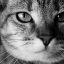

Image 2:


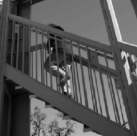

In [4]:
img1 = Image.open('image1.png')
img2 = Image.open('image2.png')
print('Image 1:')
display(img1)
print('Image 2:')
display(img2)



Image 1 original:


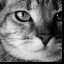

Image 1 blurred:


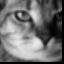

Image 1 sharpened:


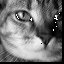

Image 2 original:


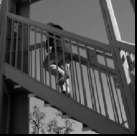

Image 2 vertical edges:


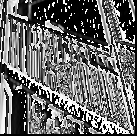

Image 2 horizontal edges:


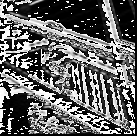

In [25]:
# Different 3 x 3 convolution filters
K_identity = np.matrix('0 0 0; 0 1 0; 0 0 0')
K_blur = np.matrix('1 1 1; 1 1 1; 1 1 1') * 1/9
K_sharpen = np.matrix('-0.18861431   0.53917223  -0.25360137;0.51823366   0.17399924  -0.23479152;0.07320452   0.14105716   0.25160035')
K_ver_edges = np.matrix('-1 0 1; -1 0 1;-1 0 1')
K_hor_edges = np.matrix('-1 -1 -1; 0 0 0; 1 1 1')

# Applying filters to example images
print('Image 1 original:')
display(array_to_img(conv2d(img_to_array(img1),K_identity)))
print('Image 1 blurred:')
display(array_to_img(conv2d(img_to_array(img1),K_blur)))
print('Image 1 sharpened:')
display(array_to_img(conv2d(img_to_array(img1),K_sharpen)))
print('Image 2 original:')
display(array_to_img(conv2d(img_to_array(img2),K_identity)))
print('Image 2 vertical edges:')
display(array_to_img(conv2d(img_to_array(img2),K_ver_edges)))
print('Image 2 horizontal edges:')
display(array_to_img(conv2d(img_to_array(img2),K_hor_edges)))




Next Step: Learning a kernel

input image
   ↓

single convolution
   ↓

output image

In [24]:
#Learning sharpening kernel to match the target image
import tensorflow as tf
conv_layers=tf.keras.layers.Conv2D(filters=1,kernel_size=3,activation=None,padding='same',strides=(1))
x=img_to_array(img1)/255.0
sharpened = Image.open('sharpened.png')
y=img_to_array(sharpened)/255.0
print(x.shape)
x=np.expand_dims(x,axis=0)#batch size
x=np.expand_dims(x,axis=-1)#channels
print(x.shape)
y=np.expand_dims(y,axis=0)#batch size
y=np.expand_dims(y,axis=-1)#channels
print(y.shape)
model=tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=1,kernel_size=3,activation=None,padding='same',strides=(1),input_shape=x.shape[1:],use_bias=False)
])
model.compile(optimizer='adam',loss='mse')
model.fit(x,y,epochs=1000)

kernel = model.layers[0].get_weights()[0]
print(kernel[:, :, 0, 0])

(64, 64)
(1, 64, 64, 1)
(1, 64, 64, 1)
Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - loss: 1.3100
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.2995
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.2891
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.2788
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.2685
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1.2582
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.2480
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.2378
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.2277
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.2176
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.2076
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1976
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.1877
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.1778
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 1.1679
Epoch 16/1000
1/

In [43]:
  #considering multiple channels
  x = np.random.randn(4,4,2)
  kernel=np.random.randn(2,2,2)

  m,l,d=x.shape
  k=kernel.shape[0]
  Y=np.zeros((m-k+1,l-k+1))

  for i in range(m-k+1):
    for j in range(l-k+1):
        val=0
        for c in range(x.shape[2]):
          for a in range(k):
            for b in range(k):
              val+=x[i+a,j+b,c] * kernel[a,b,c]
        Y[i,j]=val
  print(Y)

[[ 0.68708626  0.88551045  1.9328079 ]
 [-2.52593384  2.68908022  0.82712083]
 [-1.00971378 -4.275325    0.46927384]]


In [33]:
  import numpy as np
  #considering multiple channels
  #implementing convolution as a linear operation
  #building matrix a and b to compute c
  #x = np.random.randn(4,4,2)
  #kernel=np.random.randn(2,2,2)
  x = np.array([
    [[11,27], [12,28], [13,29], [14,30]],
    [[15,31], [16,32], [17,33], [18,34]],
    [[19,35], [20,36], [21,37], [22,38]],
    [[23,39], [24,40], [25,41], [26,42]]
  ])

  kernel = np.array([
    [[1,5], [2,6]],
    [[3,7], [4,8]]
  ])

  m,l,d=x.shape
  k=kernel.shape[0]
  A=np.zeros(((m-k+1)*(l-k+1),k*k*d))

#building A
  row=0
  for i in range(m-k+1):
    for j in range(l-k+1):
        col=0
        for c in range(d):
          for a in range(k):
            for b in range(k):
              A[row,col]=x[i+a,j+b,c]
              col+=1
        row+=1
  print("shape of A",A.shape)

#building B
  B=np.zeros((k*k*d,))

  row=0
  for c in range(d):
    for i in range(k):
      for j in range(k):
        B[row]=kernel[i,j,c]
        row+=1
  print("shape of B",B.shape)
#building Y
  Y=np.zeros((m-k+1,l-k+1))

  Y=A @ B
  print("shape of Y",Y.shape)
  print ("matrix A:" ,A,"\n", "matrix B:",B,"\n","The result is:",Y)

shape of A (9, 8)
shape of B (8,)
shape of Y (9,)
matrix A: [[11. 12. 15. 16. 27. 28. 31. 32.]
 [12. 13. 16. 17. 28. 29. 32. 33.]
 [13. 14. 17. 18. 29. 30. 33. 34.]
 [15. 16. 19. 20. 31. 32. 35. 36.]
 [16. 17. 20. 21. 32. 33. 36. 37.]
 [17. 18. 21. 22. 33. 34. 37. 38.]
 [19. 20. 23. 24. 35. 36. 39. 40.]
 [20. 21. 24. 25. 36. 37. 40. 41.]
 [21. 22. 25. 26. 37. 38. 41. 42.]] 
 matrix B: [1. 2. 3. 4. 5. 6. 7. 8.] 
 The result is: [ 920.  956.  992. 1064. 1100. 1136. 1208. 1244. 1280.]
